In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import ruptures as rpt
import multiprocessing
from concurrent import futures
from tqdm import tqdm

import sys

sys.path.append("..")

from src import IOFunctions
from IPython.display import display, clear_output

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

/tmp/ipykernel_1030320/3956807181.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
dye_data_folder = '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1/'

In [3]:
loc_files = H_F.file_search(dye_data_folder, ".h5", "")
print(f"Found {len(loc_files)} H5 files")
for i, f in enumerate(loc_files):
    print(f"  [{i}]: {os.path.basename(f)}")

Found 25 H5 files
  [0]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.h5
  [1]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.h5
  [2]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.h5
  [3]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.h5
  [4]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.h5
  [5]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.h5
  [6]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.h5
  [7]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.h5
  [8]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.h5
  [9]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_004.h5
  [10]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos00

In [4]:
tiff_files = H_F.file_search(dye_data_folder, ".tif", "")
print(f"Found {len(tiff_files)} tiff files")
for i, f in enumerate(tiff_files):
    print(f"  [{i}]: {os.path.basename(f)}")

Found 25 tiff files
  [0]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.ome.tif
  [1]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_001.ome.tif
  [2]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_002.ome.tif
  [3]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_003.ome.tif
  [4]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_004.ome.tif
  [5]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_000.ome.tif
  [6]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_001.ome.tif
  [7]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_002.ome.tif
  [8]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_003.ome.tif
  [9]: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos001_004.ome.tif
  [10]: 20pM_HJ_20p561_568lp_D

In [8]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
dichroic_mirror_all = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_red_filter = "semrock-blp01-635r"

longpass_filter = "semrock-blp01-568r"
filters = [dichroic_mirror, longpass_filter]
dye = "Cy3"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

dye = "Cy5"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

print(f"Cy3 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy3}")
print(f"Cy5 pixel efficiencies (B, G, R): {dye_pixel_efficiency_Cy5}")

Cy3 pixel efficiencies (B, G, R): [0.02106169 0.38407764 0.59486068]
Cy5 pixel efficiencies (B, G, R): [0.0597236  0.18648028 0.75379612]


In [9]:
dye_pixel_efficiency_Cy3[-1]/dye_pixel_efficiency_Cy3[-2]

1.5488031978157264

In [10]:
dye_pixel_efficiency_Cy5[-1]/dye_pixel_efficiency_Cy5[-2]

4.042229683527155

In [6]:
def filter_initial_guess(df, tol=0.01):
    """Remove datapoints where A_R, A_G, and A_B are all within tol of 0.33.
    
    These represent the initial guess that was never updated by the fitter.
    
    Args:
        df (pd.DataFrame): DataFrame with A_R, A_G, A_B columns.
        tol (float): Tolerance for comparison to 0.33.
    
    Returns:
        pd.DataFrame: Filtered DataFrame with initial guesses removed.
    """
    initial_guess_mask = (
        np.isclose(df['A_R'], 0.33, atol=tol) &
        np.isclose(df['A_G'], 0.33, atol=tol) &
        np.isclose(df['A_B'], 0.33, atol=tol)
    )
    n_removed = initial_guess_mask.sum()
    n_total = len(df)
    print(f"Removed {n_removed}/{n_total} initial guess datapoints ({100*n_removed/n_total:.1f}%)")
    return df[~initial_guess_mask].copy()

In [7]:
def find_colour_CPs(A_R, A_G, model="l2", min_size=25, jump=1):
    """Find change points jointly in A_R and A_G using multivariate detection.

    A_R and A_G are anti-correlated spectral fractions (A_R + A_G + A_B = 1),
    so a FRET transition shifts both simultaneously. Joint detection captures
    this correlated change rather than treating channels independently.

    Uses BIC penalty (log(n) * sigma^2) rather than the n * sigma^2 used for
    photoelectron traces — spectral fractions are bounded [0, 1] so the
    original penalty is orders of magnitude too conservative.

    Args:
        A_R (np.ndarray): Red spectral fraction time series.
        A_G (np.ndarray): Green spectral fraction time series.
        model (str): Cost model for ruptures.
        min_size (int): Minimum segment size.
        jump (int): Grid of change point candidates.

    Returns:
        list: Change point indices (last element is always len(signal)).
    """
    n = len(A_R)
    if n < min_size:
        return [n]
    # stack into 2D array (n_samples, 2) for multivariate detection
    signal = np.column_stack([A_R, A_G])
    dim = signal.shape[1]
    # estimate noise from per-channel variance
    sigma2 = np.nanmean([np.nanvar(A_R), np.nanvar(A_G)])
    if sigma2 == 0:
        return [n]
    # BIC penalty: log(n) * dim * sigma^2
    pen = np.log(n) * dim * sigma2
    algo = rpt.Pelt(model=model, min_size=min_size, jump=jump).fit(signal)
    my_CPs = algo.predict(pen=pen)
    return my_CPs


def find_CPs_for_puncta(args):
    """Find change points for a single punctum jointly on A_R and A_G.

    Args:
        args (tuple): (puncta_id, A_R_values, A_G_values)

    Returns:
        tuple: (puncta_id, CPs, has_changepoint)
    """
    puncta_id, A_R, A_G = args
    CPs = find_colour_CPs(A_R, A_G)
    # has changepoint if more than 1 CP
    # (ruptures always reports the final index as a CP)
    has_cp = len(CPs) > 1
    return (puncta_id, CPs, has_cp)


def find_CPs_parallel(df):
    """Run joint change point detection on all puncta in parallel.

    Args:
        df (pd.DataFrame): Filtered DataFrame with puncta_id, A_R, A_G.

    Returns:
        dict: {puncta_id: CPs} for puncta with at least one change point.
    """
    puncta_ids = df['puncta_id'].unique()

    # prepare tasks
    tasks = []
    for pid in puncta_ids:
        subset = df[df['puncta_id'] == pid].sort_values('frame')
        A_R = subset['A_R'].values.astype(np.float64)
        A_G = subset['A_G'].values.astype(np.float64)
        tasks.append((pid, A_R, A_G))

    n_workers = min(60, max(1, int(0.9 * multiprocessing.cpu_count())))
    cp_results = {}

    with futures.ProcessPoolExecutor(n_workers) as executor:
        fs = {executor.submit(find_CPs_for_puncta, task): task[0] for task in tasks}
        with tqdm(desc="Finding colour CPs", total=len(tasks), unit="punctum") as pbar:
            for f in futures.as_completed(fs):
                pbar.update()
                puncta_id, CPs, has_cp = f.result()
                if has_cp:
                    cp_results[puncta_id] = CPs

    print(f"\nPuncta with change points: {len(cp_results)}/{len(puncta_ids)} "
          f"({100*len(cp_results)/len(puncta_ids):.1f}%)")
    return cp_results

## Load data and apply filters

In [8]:
# load data - change index as needed
file_idx = 0
print(f"Loading: {os.path.basename(loc_files[file_idx])}")
df = pd.read_hdf(loc_files[file_idx])
print(f"Total datapoints: {len(df)}")
print(f"Unique puncta: {df['puncta_id'].nunique()}")
print(f"Columns: {list(df.columns)}")

Loading: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.h5
Total datapoints: 148105
Unique puncta: 494
Columns: ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G', 'bg_R', 'A_B', 'A_G', 'A_R', 'chi_sqr', 'xc_err', 'yc_err', 's_x_err', 's_y_err', 'bg_B_err', 'bg_G_err', 'bg_R_err', 'A_B_err', 'A_G_err', 'A_R_err', 'puncta_id', 'frame', 'photons', 'background_photons']


In [9]:
# step 1: remove datapoints where A_R, A_G, A_B are all ~0.33 (initial guess)
df_filtered = filter_initial_guess(df, tol=0.01)
print(f"Remaining datapoints: {len(df_filtered)}")
print(f"Remaining puncta: {df_filtered['puncta_id'].nunique()}")

Removed 18013/148105 initial guess datapoints (12.2%)
Remaining datapoints: 130092
Remaining puncta: 494


In [10]:
# step 2: find change points in A_R and A_G channels
cp_results = find_CPs_parallel(df_filtered)

Finding colour CPs: 100%|████████████████| 494/494 [00:06<00:00, 71.12punctum/s]


Puncta with change points: 361/494 (73.1%)


In [11]:
# step 3: keep only puncta with at least one change point
cp_puncta_ids = list(cp_results.keys())
df_cp = df_filtered[df_filtered['puncta_id'].isin(cp_puncta_ids)].copy()
print(f"Puncta with change points: {len(cp_puncta_ids)}")
print(f"Datapoints in filtered dataset: {len(df_cp)}")

Puncta with change points: 361
Datapoints in filtered dataset: 110903


## Visualise puncta with change points

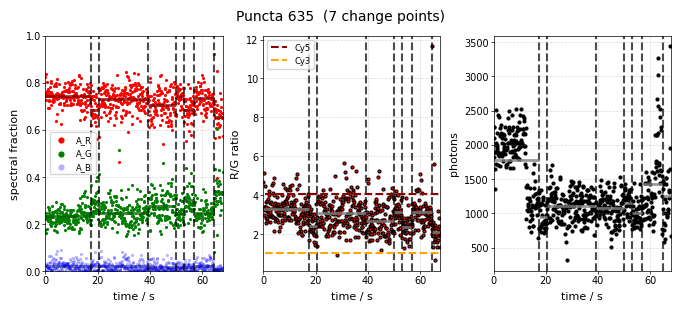

In [13]:
exposure_time = 0.1  # seconds per frame

for pid in sorted(cp_puncta_ids):
    subset = df_cp[df_cp['puncta_id'] == pid].sort_values('frame')
    if len(subset) < 5:
        continue

    CPs = cp_results[pid]
    t = subset['frame'].values * exposure_time
    ratio = subset['A_R'].values / subset['A_G'].values
    photons = subset['photons'].values

    fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1, 1, 1])
    if len(CPs)-1 > 1:
        fig.suptitle(f"Puncta {pid}  ({len(CPs)-1} change points)", fontsize=10)
    else:
        fig.suptitle(f"Puncta {pid}  ({len(CPs)-1} change point)", fontsize=10)

    # segment boundaries: [0, cp1, cp2, ..., len(signal)]
    boundaries = [0] + list(CPs)

    # panel 1: A_R and A_G vs time with change points
    axs[0] = plotter.scatter_plot(axs[0], t, subset['A_R'].values, s=5, facecolor='red', lw=0, label='A_R')
    axs[0] = plotter.scatter_plot(axs[0], t, subset['A_G'].values, s=5, facecolor='green', lw=0, label='A_G')
    axs[0] = plotter.scatter_plot(axs[0], t, subset['A_B'].values, s=5, facecolor='blue', lw=0, label='A_B', alpha=0.3)
    for cp_idx in CPs[:-1]:
        if cp_idx < len(t):
            axs[0].axvline(x=t[cp_idx], color='black', ls='--', alpha=0.7, lw=1.5)
    # segment-mean spectral fractions
    for i in range(len(boundaries) - 1):
        seg_start = boundaries[i]
        seg_end = min(boundaries[i + 1], len(t))
        if seg_end <= seg_start:
            continue
        t_start = t[seg_start]
        t_end = t[seg_end - 1]
        axs[0].hlines(y=np.nanmean(subset['A_R'].values[seg_start:seg_end]), xmin=t_start, xmax=t_end, color='darkred', ls='-', lw=2, alpha=0.8)
        axs[0].hlines(y=np.nanmean(subset['A_G'].values[seg_start:seg_end]), xmin=t_start, xmax=t_end, color='darkgreen', ls='-', lw=2, alpha=0.8)
        axs[0].hlines(y=np.nanmean(subset['A_B'].values[seg_start:seg_end]), xmin=t_start, xmax=t_end, color='darkblue', ls='-', lw=2, alpha=0.5)
    axs[0].set_xlabel('time / s')
    axs[0].set_ylabel('spectral fraction')
    axs[0].set_ylim([0, 1])
    axs[0].legend(fontsize=6, markerscale=2)

    # panel 2: R/G ratio vs time with segment averages
    axs[1] = plotter.scatter_plot(
        axs[1], x=t, y=ratio, xaxislabel='time / s',
        yaxislabel='R/G ratio', facecolor='red'
    )
    for cp_idx in CPs[:-1]:
        if cp_idx < len(t):
            axs[1].axvline(x=t[cp_idx], color='black', ls='--', alpha=0.7, lw=1.5)
    # segment-mean R/G ratio
    for i in range(len(boundaries) - 1):
        seg_start = boundaries[i]
        seg_end = min(boundaries[i + 1], len(t))
        if seg_end <= seg_start:
            continue
        seg_mean = np.nanmean(ratio[seg_start:seg_end])
        t_start = t[seg_start]
        t_end = t[seg_end - 1]
        axs[1].hlines(y=seg_mean, xmin=t_start, xmax=t_end, color='grey', ls='-', lw=2, alpha=0.8)
    # reference lines for Cy3/Cy5
    xmin, xmax = axs[1].get_xlim()
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1],
        xmin=xmin, xmax=xmax, ls='--', color='darkred', label='Cy5'
    )
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy3[2] / dye_pixel_efficiency_Cy3[1],
        xmin=xmin, xmax=xmax, ls='--', color='orange', label='Cy3'
    )
    axs[1].set_xlim([xmin, xmax])
    ymin, ymax = axs[1].get_ylim()
    if dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1] > ymax:
        axs[1].set_ylim(ymin, 1.1 * (dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1]))
    axs[1].legend(fontsize=6)

    # panel 3: photons vs time with segment averages
    axs[2] = plotter.scatter_plot(
        axs[2], x=t, y=photons, xaxislabel='time / s',
        yaxislabel='photons', facecolor='black'
    )
    for cp_idx in CPs[:-1]:
        if cp_idx < len(t):
            axs[2].axvline(x=t[cp_idx], color='black', ls='--', alpha=0.7, lw=1.5)
    # segment-mean photons
    for i in range(len(boundaries) - 1):
        seg_start = boundaries[i]
        seg_end = min(boundaries[i + 1], len(t))
        if seg_end <= seg_start:
            continue
        t_start = t[seg_start]
        t_end = t[seg_end - 1]
        axs[2].hlines(y=np.nanmean(photons[seg_start:seg_end]), xmin=t_start, xmax=t_end, color='grey', ls='-', lw=2, alpha=0.8)
    for i in np.arange(3):
        axs[i].set_xlim([0, t_end])
    clear_output(wait=True)
    folder_tosave = os.path.join(os.path.split(loc_files[file_idx])[0],  os.path.split(loc_files[file_idx])[1].split('.h5')[0])
    if not os.path.isdir(folder_tosave):
        os.mkdir(folder_tosave)
    plt.savefig(os.path.join(folder_tosave, 'PunctaID_'+str(pid).zfill(4)+'.svg'), dpi=600, format='svg')
    plt.show()

In [23]:
from src import sCMOSFunctions                                                                                         

sCMOS = sCMOSFunctions.sCMOS_Functions()                                                                               
                                                                                            
# find TIFF associated with the H5 file
tiff_file = tiff_files[file_idx]
if not os.path.exists(tiff_file):
   for ext in ['.tiff', '.TIF', '.TIFF']:
       alt = loc_files[file_idx].rsplit('.', 1)[0] + ext
       if os.path.exists(alt):
           tiff_file = alt
           break
print(f"TIFF file: {os.path.basename(tiff_file)}")

# load ROI metadata
metadata_files = H_F.file_search(dye_data_folder, "metadata", "")
x_coord, y_coord, roi_width, roi_height = IO.metadata_reader_imageJ(metadata_files[0])
print(f"ROI: x={x_coord}, y={y_coord}, w={roi_width}, h={roi_height}")

# load full TIFF stack and crop to ROI
print("Loading TIFF stack...")
raw_stack = IO.read_tiff(tiff_file)

# demosaic with simple bilinear interpolation (no variance weighting)
print("Demosaicing with bilinear interpolation...")
rgb_stack, _ = sCMOS.bayer_demosaic_stack(raw_stack, strategy='bilinear')
rgb_stack = rgb_stack[:, :, :, ::-1]

# convert RGB to uint8
vmin_rgb, vmax_rgb = np.percentile(rgb_stack, [1, 99.5])
rgb_uint8 = np.clip((rgb_stack - vmin_rgb) / (vmax_rgb - vmin_rgb) * 255, 0, 255).astype(np.uint8)
print(f"RGB uint8 stack shape: {rgb_uint8.shape}")

# display range for raw data
vmin_raw, vmax_raw = np.percentile(raw_stack, [1, 99.5])
print("Done.")

TIFF file: 20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000.ome.tif
ROI: x=344, y=856, w=648, h=648
Loading TIFF stack...
Demosaicing with bilinear interpolation...
RGB uint8 stack shape: (1000, 648, 648, 3)
Done.


In [24]:
output_dir = os.path.join(folder_tosave, "gifs")                                                                     
os.makedirs(output_dir, exist_ok=True)
                                                                                                                      
ROI_size = 18                                                                                
half_roi = ROI_size // 2
extra_frames = 20  # frames past the last frame in the cleaned data
fps = 10
pixel_size = 69  # nm

n_total_frames = raw_stack.shape[0]

for pid in tqdm(sorted(cp_puncta_ids), desc="Creating GIFs"):
   subset = df_cp[df_cp['puncta_id'] == pid].sort_values('frame')
   if len(subset) < 5:
       continue

   # puncta position (median across frames for stability)
   xc = int(np.round(subset['xc'].median()))
   yc = int(np.round(subset['yc'].median()))

   # frame range: first frame to last frame + extra (continuous, no pruning)
   first_frame = int(subset['frame'].min())
   last_frame = min(int(subset['frame'].max()) + extra_frames, n_total_frames - 1)
   frame_range = np.arange(first_frame, last_frame + 1)

   # ROI bounds with boundary checks
   y_start = max(0, yc - half_roi)
   y_end = min(raw_stack.shape[1], yc + half_roi)
   x_start = max(0, xc - half_roi)
   x_end = min(raw_stack.shape[2], xc + half_roi)

   # extract ROIs for all frames in range (no pruning)
   raw_roi = raw_stack[frame_range][:, y_start:y_end, x_start:x_end]
   rgb_roi = rgb_uint8[frame_range][:, y_start:y_end, x_start:x_end, :]

   # convert raw to pseudo-RGB uint8 for vertical stacking
   raw_norm = np.clip(
       (raw_roi - vmin_raw) / (vmax_raw - vmin_raw) * 255, 0, 255
   ).astype(np.uint8)
   raw_rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

   # white separator line (2 px)
   roi_w = raw_rgb.shape[2]
   sep = np.ones((len(frame_range), 2, roi_w, 3), dtype=np.uint8) * 255

   # stack: raw (top) | separator | RGB (bottom)
   stacked = np.concatenate([raw_rgb, sep, rgb_roi], axis=1)

   gif_path = os.path.join(output_dir, f"puncta_{pid}.gif")
   plotter.make_animated_gif(
       stacked, gif_path,
       fps=fps, dpi=150,
       width=3, height=6,
       pixelsize=pixel_size,
       scalebarsize=300,
       scalebarlabel="300 nm",
   )
   plt.close('all')

print(f"\nSaved {len(cp_puncta_ids)} GIFs to {output_dir}")

Creating GIFs:   0%|                                    | 0/361 [00:00<?, ?it/s]/home/jsb92/Documents/pyBayerSMLM/src/PlottingBase.py:1513: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
Creating GIFs:   0%|                          | 1/361 [00:30<3:05:40, 30.95s/it]/home/jsb92/Documents/pyBayerSMLM/src/PlottingBase.py:1513: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
Creating GIFs:   1%|▏                         | 2/361 [00:53<2:36:15, 26.12s/it]/home/jsb92/Documents/pyBayerSMLM/src/PlottingBase.py:1513: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0, right=1, 


Saved 361 GIFs to /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260202_HollidayJunctions/200mMMgCl2/20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1/20pM_HJ_20p561_568lp_DC2_emptyfilterweheel_100msExposure_1_MMStack_2-Pos000_000/gifs


In [ ]:
# summary statistics
print("=" * 60)
print("Post-hoc analysis summary")
print("=" * 60)
print(f"Total datapoints loaded:              {len(df)}")
print(f"Removed (initial guess ~0.33):         {len(df) - len(df_filtered)}")
print(f"Total puncta:                          {df['puncta_id'].nunique()}")
print(f"Puncta with change points (A_R+A_G):   {len(cp_puncta_ids)}")
print(f"Datapoints in final dataset:           {len(df_cp)}")
print()
# breakdown of CP counts
n_cps = [len(cp_results[pid]) - 1 for pid in cp_puncta_ids]
print(f"Change points per punctum (joint): mean={np.mean(n_cps):.1f}, max={np.max(n_cps)}")